In [1]:
!pip install numpy matplotlib


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 -4*x +5

In [4]:
f(3)

20

In [5]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
ys

array([100.    ,  91.6875,  83.75  ,  76.1875,  69.    ,  62.1875,
        55.75  ,  49.6875,  44.    ,  38.6875,  33.75  ,  29.1875,
        25.    ,  21.1875,  17.75  ,  14.6875,  12.    ,   9.6875,
         7.75  ,   6.1875,   5.    ,   4.1875,   3.75  ,   3.6875,
         4.    ,   4.6875,   5.75  ,   7.1875,   9.    ,  11.1875,
        13.75  ,  16.6875,  20.    ,  23.6875,  27.75  ,  32.1875,
        37.    ,  42.1875,  47.75  ,  53.6875])

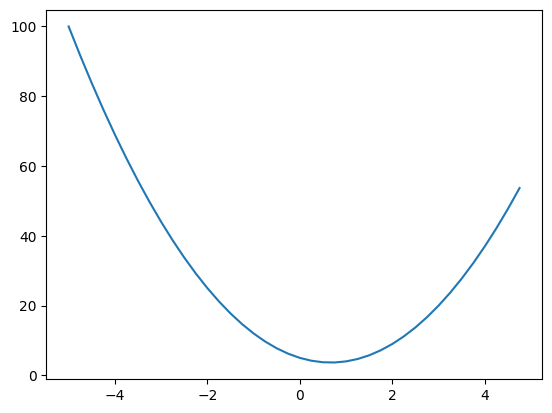

In [6]:
plt.plot(xs,ys)

In [7]:
h = 0.000001
x = 2.0/3
(f(x+h) - f(x))/h

2.999378523327323e-06

In [8]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
d

4.0

In [9]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0
d1 = a*b + c
c += h
d2 = a*b + c

print("d1", d1)
print("d2", d2)
print("slope", (d2 - d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [303]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda : None
        self.label= label
        self.grad = 0.0 #derivative of l wrt a particular node in the graph 

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        data = self.data + other.data
        out =  Value(data,(self,other),_op='+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __pow__(self,other):
        assert isinstance(other, (int,float))
        out = Value(self.data ** other,(self,), f'**{other}')

        def _backward():
            self.grad += other * self.data **(other - 1) * out.grad
        out._backward=_backward
        return out
        
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        data = self.data * other.data
        out =  Value(data,(self,other),_op='*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other): #other * self
        return self * other
        
    def __truediv__(self,other):
        return self * other ** -1

    def __sub__(self,other):
        return self + (-other)

    def __neg__(self):
        return -1 * self
            
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def __rmul__(self,other): #other * self
        return self * other
            
    def exp(self):
        x = self.data
        t = math.exp(x)
        out = Value(t, (self, ), 'exp')

        def _backward():
            self.grad += t * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)  # visit children first
                topo.append(v)        # then add self
        self.grad = 1.0
        build_topo(self)
        
        for node in reversed(topo):
            node._backward()
        

a = Value(2.0,label='a')
b = Value(-3.0,label='b')
c=Value(10.0,label='c')
e = a*b #a.__add__(b)
e.label ='e'
d = e + c
d.label='d'
f = Value(-2.0,label='f')
L = f * d #output
L.label = 'L'

In [221]:
a = Value(6.0)
b = Value(2.0)
a - b

Value(data = 4.0)

In [11]:
!pip install graphviz


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [169]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label , n.data, n.grad ), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [19]:
import os
os.environ['PATH'] += r';C:\Program Files\Graphviz\bin'

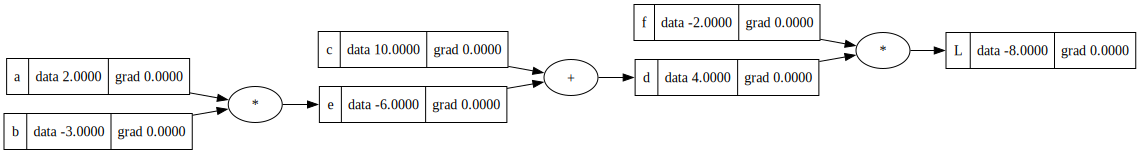

In [171]:
draw_dot(L)

In [85]:
L.grad = 1.0

In [86]:
d.grad = -2.0
f.grad = 4.0

In [87]:
e.grad = -2.0
c.grad = -2.0

In [88]:
a.grad = -2.0 * -3.0
b.grad = -2.0 * 2.0

In [92]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b 
d = e + c
L = f * d 

print(L.data)


-7.286496


In [180]:
def lol():
    h = 0.001
    a = Value(2.0,label='a')
    b = Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e = a*b #a.__add__(b)
    e.label ='e'
    d = e +c
    d.label='d'
    f = Value(-2.0,label='f')
    L = f * d #output
    L.label = 'L'
    L1 = L.data

    a = Value(2.0,label='a')
    b = Value(-3.0,label='b')
    c=Value(10.0,label='c')
    e = a*b #a.__add__(b)
    e.label ='e'
    d = e + c
    d.label='d'
    f = Value(-2.0,label='f')
    L = f * d #output
    L.label = 'L'
    L2 = L.data + h
    
    print((L2-L1)/h)

lol()

1.000000000000334


In [223]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137358, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh()
o.label = 'o'

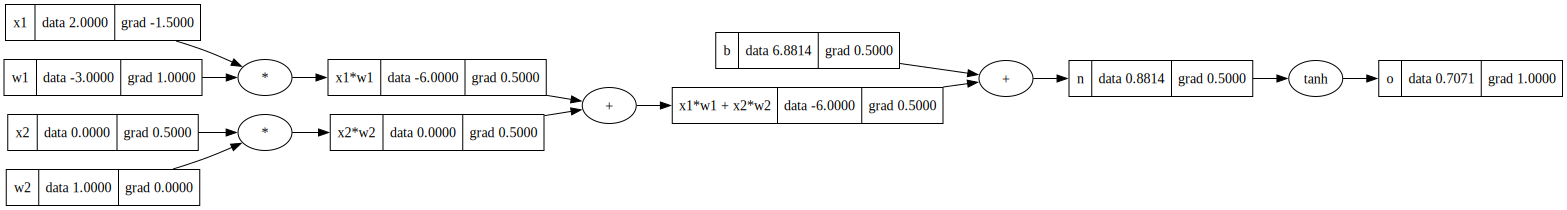

In [225]:
draw_dot(o)

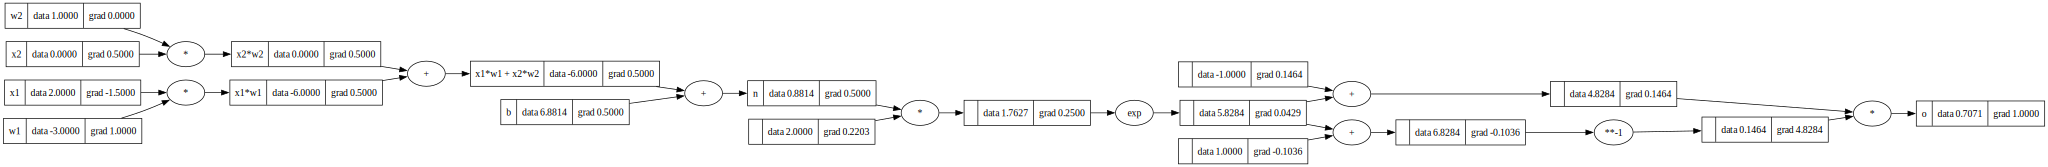

In [227]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.88137358, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e-1)/(e+1)

o.label = 'o'
o.backward()
draw_dot(o)

In [224]:
o.backward()

In [156]:
topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)  # visit children first
        topo.append(v)        # then add self

build_topo(o)
topo

[Value(data = -3.0),
 Value(data = 2.0),
 Value(data = -6.0),
 Value(data = 0.0),
 Value(data = 1.0),
 Value(data = 0.0),
 Value(data = -6.0),
 Value(data = 6.88137358),
 Value(data = 0.88137358),
 Value(data = 0.707106777676776)]

In [158]:
o.grad = 1.0

topo = []
visited = set()

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)  # visit children first
        topo.append(v)        # then add self

build_topo(o)

for node in reversed(topo):
    node._backward()
    


In [144]:
o.grad = 1.0
o._backward()

In [146]:
n._backward()

In [148]:
x1w1x2w2._backward()

In [151]:
x1w1._backward()
x2w2._backward()

In [117]:
o.grad = 1.0
n.grad = 0.5
x1w1x2w2.grad = 0.5
b.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [119]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
w1.grad = x1.data * x1w1.grad
x1.grad = w1.data * x1w1.grad

In [112]:
#do/dn = 1 - tanhn**2
o.data
1 - o.data**2


0.5000000049635664

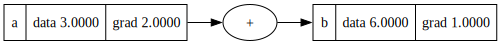

In [186]:
a = Value(3.0,label = 'a')
b = a + a
b.label ='b'
b.backward()
draw_dot(b)

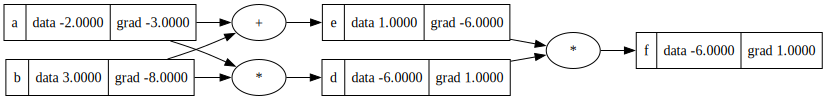

In [187]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b ; d.label = 'd'
e = a + b ; e.label = 'e'
f = d * e ; f.label = 'f'

f.backward()

draw_dot(f)

In [229]:
!pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   - -------------------------------------- 3.9/123.0 MB 21.1 MB/s eta 0:00:06
   - -------------------------------------- 5.8/123.0 MB 14.6 MB/s eta 0:00:09
   -- ------------------------------------- 7.9/123.0 MB 14.0 MB/s eta 0:00:09
   --- ------------------------------------ 11.3/123.0 MB 14.0 MB/s eta 0:00:08
   ----- ---------------------------------- 16.3/123.0 MB 16.1 MB/s eta 0:00:07
   ------ --------------------------------- 20.4/123.0 MB 16.7 MB/s eta 0:00:07
   ------- -------------------------------- 24.4/123.0 MB 17.2 MB/s eta 0:00:06
   --------- ------------------------------ 28.6/123.0 MB 17.6 MB/s eta 0:00:06
   ---------- ----------------------------- 33.6/123.0 MB 18.3 MB/s eta 0:00:05
   ---------- ----------------------------- 33.6/123.0 MB 18.3 MB/s eta 0:00:05
   ----


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [231]:
import torch

x1 = torch.Tensor([2.0]).double()          ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()          ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()         ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()          ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double() ; b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [233]:
import random

In [349]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))
    
    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
    
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        
x = [2.0, 3.0, -1.0]
n = MLP(3,[4,4,1])
n(x) #calls __call__

Value(data = -0.26992463188166005)

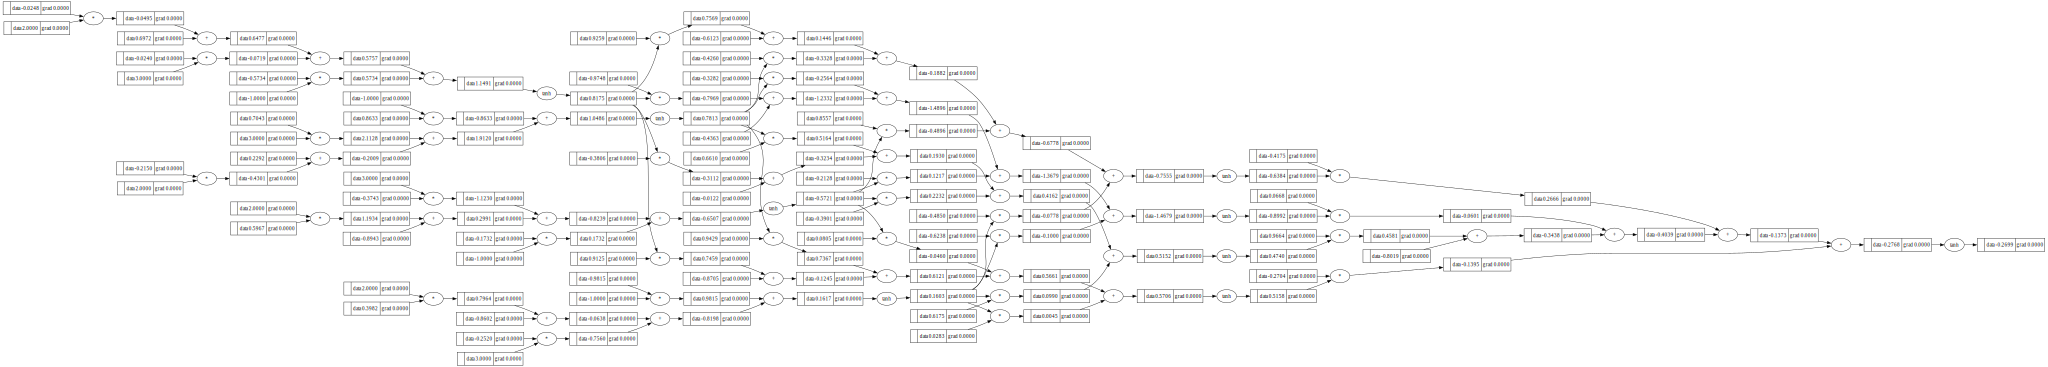

In [350]:
draw_dot(n(x))

In [351]:
xs = [
    [2.0, 3.0, -1.0],   # input 1
    [3.0, -1.0, 0.5],   # input 2
    [0.5, 1.0, 1.0],    # input 3
    [1.0, 1.0, -1.0],   # input 4
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired outputs (targets)

In [352]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt,yout in zip(ys,ypred))
loss 

Value(data = 4.972929119475357)

In [353]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt,yout in zip(ys,ypred))
loss 

Value(data = 4.972929119475357)

In [308]:
loss.backward()

In [354]:
n.parameters()


[Value(data = -0.024751140510600456),
 Value(data = -0.023979212671621397),
 Value(data = -0.57342381053007),
 Value(data = 0.6971587663948415),
 Value(data = -0.21503393346098498),
 Value(data = 0.7042798726536932),
 Value(data = 0.8633288190327641),
 Value(data = 0.2292056075318245),
 Value(data = 0.5967095524668975),
 Value(data = -0.37434259263235603),
 Value(data = -0.17320639615597933),
 Value(data = -0.8943033042779025),
 Value(data = 0.39821967259613955),
 Value(data = -0.25199030321315585),
 Value(data = -0.9814575156166749),
 Value(data = -0.8602233069353891),
 Value(data = -0.3806318113627247),
 Value(data = 0.6609770704169495),
 Value(data = -0.39005960689341657),
 Value(data = 0.6174562892197082),
 Value(data = -0.012226343115077754),
 Value(data = -0.974802333132591),
 Value(data = -0.3281513826825393),
 Value(data = -0.21279112411601675),
 Value(data = -0.6238070789265473),
 Value(data = -0.4363480161271227),
 Value(data = 0.9258733064143418),
 Value(data = -0.4260030162

In [317]:
n.layers[0].neurons[0].w[0].data

0.30815000029396566

In [318]:
n.layers[0].neurons[0].w[0].grad

3.3323194908464218

In [332]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [329]:
n.layers[0].neurons[0].w[0].data

0.2415036104770372

In [355]:
ypred

[Value(data = -0.26992463188166005),
 Value(data = -0.9069482011356162),
 Value(data = -0.17822762144763077),
 Value(data = -0.635925447382023)]

In [370]:
for k in range(20):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt,yout in zip(ys,ypred))

    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.09 * p.grad

    print(k , loss.data)
    

0 0.004297638458542991
1 0.00425095308895824
2 0.004205216957192923
3 0.004160401993128305
4 0.004116481210769745
5 0.0040734286567503325
6 0.004031219361729361
7 0.003989829294498211
8 0.003949235318619828
9 0.003909415151440561
10 0.0038703473253248587
11 0.0038320111509738334
12 0.0037943866826984814
13 0.0037574546855277105
14 0.003721196604039187
15 0.003685594532809083
16 0.0036506311883837024
17 0.0036162898826828205
18 0.003582554497750015
19 0.0035494094617716278


In [371]:
ypred

[Value(data = 0.9734865117614622),
 Value(data = -0.9805896084551134),
 Value(data = -0.9630124620519553),
 Value(data = 0.9668095926537095)]